# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [4]:
data = pd.read_csv('data/banknote_authentication.csv' )

In [5]:
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


## Problem 

### C.

Use k-fold cross validation to find the optimal number of gaussian components for each class. As before calculate the confusion matrix, AUC score and plot the ROC curve for the best classifier. Assume that maximal number of components in each class is 12.  

__Hint__ use the `StratifiedKFold` function from scikit-learn library to generate folds. 

Best components for class 0: 11
Best components for class 1: 11
Best CV AUC: 0.9915790598339734
Confusion matrix:
[[148   5]
 [  7 115]]
Test AUC: 0.9936247723132969


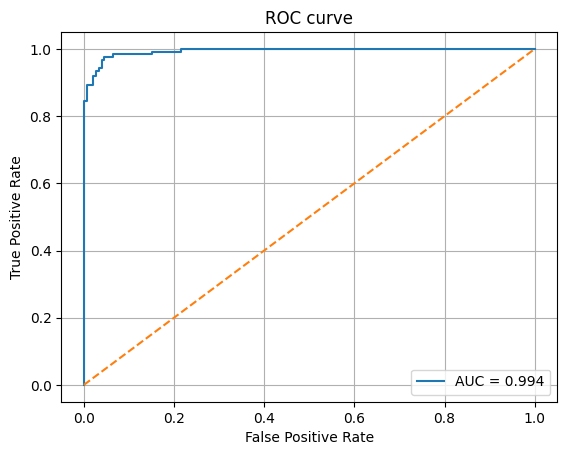

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

X = data.drop(columns="counterfeit")
y = data["counterfeit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

def gmm_proba(X_tr, y_tr, X_val, k0, k1):
    y_tr = np.array(y_tr)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    gmm0 = GaussianMixture(n_components=k0, random_state=42).fit(X_tr[y_tr == 0])
    gmm1 = GaussianMixture(n_components=k1, random_state=42).fit(X_tr[y_tr == 1])

    log_p0 = gmm0.score_samples(X_val) + np.log(np.mean(y_tr == 0))
    log_p1 = gmm1.score_samples(X_val) + np.log(np.mean(y_tr == 1))

    p1 = np.exp(log_p1) / (np.exp(log_p0) + np.exp(log_p1))
    return p1


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_auc = -1
best_k0 = None
best_k1 = None

for k0 in range(1, 13):
    for k1 in range(1, 13):

        aucs = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr = X_train.iloc[train_idx]
            X_val = X_train.iloc[val_idx]
            y_tr = y_train.iloc[train_idx]
            y_val = y_train.iloc[val_idx]

            proba = gmm_proba(X_tr, y_tr, X_val, k0, k1)
            aucs.append(roc_auc_score(y_val, proba))

        mean_auc = np.mean(aucs)

        if mean_auc > best_auc:
            best_auc = mean_auc
            best_k0 = k0
            best_k1 = k1

print("Best components for class 0:", best_k0)
print("Best components for class 1:", best_k1)
print("Best CV AUC:", best_auc)


test_proba = gmm_proba(X_train, y_train, X_test, best_k0, best_k1)
test_pred = (test_proba >= 0.5).astype(int)

print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred))

auc = roc_auc_score(y_test, test_proba)
print("Test AUC:", auc)

fprs, tprs, thds = roc_curve(y_test, test_proba)

plt.plot(fprs, tprs, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid()
plt.show()

## D.  

Assume that 1% of all the customers in your store try to pay with a counterfeit 100PLN bill. If you accept the counterfeit bill you loose 100PLN. If you reject a valid bill,  you may loose the purchase, you estimate this loss as 15PLN on average. For each of the three classifiers find the threshold that minimises your losses and calculates the minimum loss for each classifier. Show the optimal classifiers points on the ROC curves.

AUC: 0.9936247723132969
Best threshold: 0.9240716698301857
Minimum expected loss per customer: 0.15573770491803274
Minimum expected loss per 1000 customers: 155.73770491803273
Confusion matrix:
[[153   0]
 [ 19 103]]


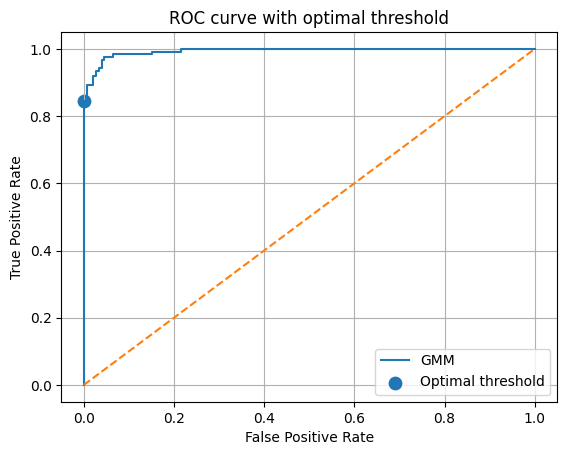

In [7]:
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

fprs, tprs, thds = roc_curve(y_test, test_proba)

p_fake = 0.01
p_valid = 0.99

losses = 100 * p_fake * (1 - tprs) + 15 * p_valid * fprs

best_id = np.argmin(losses)
best_threshold = thds[best_id]

print("AUC:", roc_auc_score(y_test, test_proba))
print("Best threshold:", best_threshold)
print("Minimum expected loss per customer:", losses[best_id])
print("Minimum expected loss per 1000 customers:", losses[best_id] * 1000)

y_pred = (test_proba >= best_threshold).astype(int)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

plt.plot(fprs, tprs, label="GMM")
plt.scatter(fprs[best_id], tprs[best_id], s=80, label="Optimal threshold")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve with optimal threshold")
plt.legend()
plt.grid()
plt.show()

In [8]:
fprs, tprs, thds = roc_curve(y_test, test_proba)

In [9]:
fprs

array([0.        , 0.        , 0.        , 0.00653595, 0.00653595,
       0.01960784, 0.01960784, 0.02614379, 0.02614379, 0.03267974,
       0.03267974, 0.03921569, 0.03921569, 0.04575163, 0.04575163,
       0.06535948, 0.06535948, 0.1503268 , 0.1503268 , 0.21568627,
       0.21568627, 0.37908497, 0.39215686, 1.        ])

In [10]:
tprs

array([0.        , 0.10655738, 0.8442623 , 0.8442623 , 0.89344262,
       0.89344262, 0.91803279, 0.91803279, 0.93442623, 0.93442623,
       0.94262295, 0.94262295, 0.96721311, 0.96721311, 0.97540984,
       0.97540984, 0.98360656, 0.98360656, 0.99180328, 0.99180328,
       1.        , 1.        , 1.        , 1.        ])